# Task 2: Прогнозирование PM2.5 в Павлодаре

Простая базовая модель: линейная регрессия предсказывает среднесуточный PM2.5 по значениям за два предыдущих дня (лаги).

Расширенная версия (погода, другие загрязнители, случайный лес, важность признаков) — в `Task1_AirQuality_Analysis.ipynb`, раздел 11.

In [1]:
import os

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error

DATA_DIR = "data"

In [2]:
# Загружаем часовые данные PM2.5 и оставляем только Павлодар
df = pd.read_csv(os.path.join(DATA_DIR, "pm2_5.csv"))
df = df[df["city"].str.contains("Pavlodar", case=False, na=False)]

# В исходнике смешаны смещения -08:00 и -07:00 (летнее время), поэтому utc=True обязателен —
# без него pandas не может собрать единый столбец дат (это и ломало старую версию).
df["datetime"] = pd.to_datetime(df["datetime_utc"], utc=True).dt.tz_convert("Asia/Almaty")

# Среднесуточное значение по всем постам города
daily = df.set_index("datetime").resample("D")["value_ugm3"].mean().to_frame(name="pm2_5")

In [3]:
# Признаки = значения за 1 и 2 дня назад. shift() делаем ДО dropna(), чтобы при разрыве в данных
# лаг не «перепрыгивал» через пропущенные дни (иначе «вчера» могло бы оказаться полгода назад).
daily["pm2_5_lag1"] = daily["pm2_5"].shift(1)
daily["pm2_5_lag2"] = daily["pm2_5"].shift(2)
daily = daily.dropna()

X = daily[["pm2_5_lag1", "pm2_5_lag2"]]
y = daily["pm2_5"]

# Хронологическое разбиение 80/20 (без перемешивания — это временной ряд)
split = int(len(daily) * 0.8)
X_train, X_test, y_train, y_test = X.iloc[:split], X.iloc[split:], y.iloc[:split], y.iloc[split:]
print(f"Тренировочный набор: {len(X_train)} дней, тестовый: {len(X_test)} дней")

Тренировочный набор: 1004 дней, тестовый: 251 дней


In [4]:
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

# Сравниваем с наивным прогнозом «завтра = сегодня», чтобы понять, есть ли от модели польза
mae = mean_absolute_error(y_test, y_pred)
mae_naive = mean_absolute_error(y_test, X_test["pm2_5_lag1"])
rmse = mean_squared_error(y_test, y_pred) ** 0.5
print(f"MAE модели: {mae:.2f} µg/m³ | RMSE: {rmse:.2f} | MAE наивного прогноза: {mae_naive:.2f}")
print(f"Коэффициенты: lag1 = {model.coef_[0]:.2f}, lag2 = {model.coef_[1]:.2f}, свободный член = {model.intercept_:.2f}")

MAE модели: 2.76 µg/m³ | RMSE: 3.40 | MAE наивного прогноза: 2.22
Коэффициенты: lag1 = 0.56, lag2 = 0.06, свободный член = 3.94


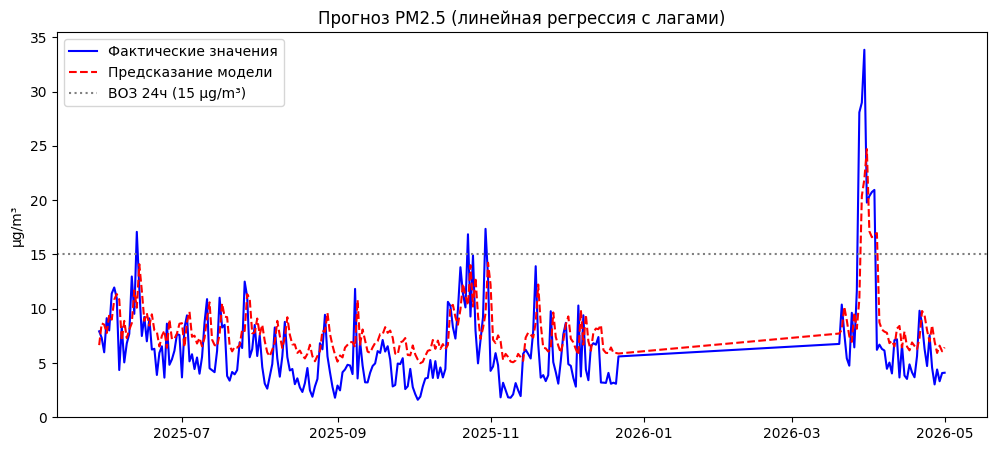

In [5]:
plt.figure(figsize=(12, 5))
plt.plot(y_test.index, y_test, label="Фактические значения", color="blue")
plt.plot(y_test.index, y_pred, label="Предсказание модели", color="red", linestyle="--")
plt.axhline(15, color="grey", linestyle=":", label="ВОЗ 24ч (15 µg/m³)")
plt.title("Прогноз PM2.5 (линейная регрессия с лагами)")
plt.ylabel("µg/m³")
plt.legend()
plt.show()

### Вывод

Эта базовая модель работает на **сырых** данных без контроля качества: у поста PCP #5 PM-датчик месяцами «залипает» на ~1 µg/m³, и среднее по городу скачет в зависимости от того, какие посты работают. Поэтому она **проигрывает** даже наивному прогнозу «завтра = сегодня». После очистки данных и добавления погоды (Task 1, раздел 11) линейная регрессия уже обгоняет наивный прогноз — это наглядно показывает, что качество данных важнее выбора модели.